# Winner EDA: transaction reference, V/ID, UID와 시간 일관성
원본 CSV에서 [Transaction Columns Reference](https://www.kaggle.com/alijs1/ieee-transaction-columns-reference)의 열별 요약과
[V/ID EDA](https://www.kaggle.com/cdeotte/eda-for-columns-v-and-id)의 결측 묶음·상관관계·열 선택을 확인한다.
[Part 1](https://www.kaggle.com/c/ieee-fraud-detection/discussion/111284), [Part 2](https://www.kaggle.com/competitions/ieee-fraud-detection/writeups/fraudsquad-1st-place-solution-part-2),
[How to Find UIDs](https://www.kaggle.com/c/ieee-fraud-detection/discussion/111510)의 UID 순도·알려진/새로운 고객·시간 일관성도 직접 측정한다.
전처리 파일이나 모델 실험 산출물에 의존하지 않는다. 공개 정밀 UID 분석에서만 추가 데이터셋 version 2를 사용한다.

## 이 노트북을 읽는 방법

코드를 실행하기 전에 바로 위의 설명을 읽어보세요. **어떤 질문을 푸는지 → 작은 예시로 계산 → 실제 코드의 변수와 연결 → 출력 해석** 순서로 설명합니다.
코드 아래의 관찰은 이미 저장된 실행 결과를 읽는 안내입니다. '해볼 실험'은 아직 실행하지 않은 제안이며, 실제 결과와 구분했습니다.

처음 읽을 때 함수 이름을 모두 외울 필요는 없습니다. 새 피처를 만날 때마다 **'이 숫자는 무엇을 요약하며, 예측할 때도 알 수 있는가?'**를 물어보세요.
EDA에서 찾은 차이가 모델 성능 개선을 뜻하지는 않습니다. 실험 노트북에서는 **검증 데이터를 정한 뒤 구성 요소 하나씩 비교**해야 개선의 근거를 얻습니다.

처음에는 `01_eda_report` → GitHub `baseline`을 읽고, 이후 `02_winner_eda` → `winner_xgb` → `winner_lgbm` → `winner_catboost` → `winner_blend`로 이어가세요.
우승자 공개 baseline과 최종 우승 제출 전체는 구분합니다.

설명을 보강하면서 학습 코드·기존 표·그래프·실행 범위를 유지했습니다. 이 노트북의 **저장된 출력**과 설정의 **다음 실행 기본값**이 다를 수 있으므로 첫 실행 범위와 metrics를 먼저 확인하세요.


### 처음 만나는 용어는 여기서 잠깐 확인하세요

| 용어 | 여기서 뜻하는 것 |
|---|---|
| 피처(feature) | 모델에 입력할 거래의 정보. 원본 열과 새로 계산한 열 모두 포함 |
| NaN / 결측 | 값이 관측되지 않음. 실제 숫자 0과 다른 상태 |
| fold / validation | 교차검증의 한 분할 / 그 분할에서 평가용으로 제외한 데이터 |
| OOF | 각 train 행을 그 행 없이 학습한 모델로 예측해서 모은 값 |
| smoke | 전체 학습 전에 축소 데이터·rounds로 실행 흐름을 확인하는 실험 |
| leaf | tree에서 조건을 따라 내려간 끝의 구역. 그 구역에 들어온 행에 같은 보정을 줌 |

**제거 실험(ablation)**은 피처나 기법 하나를 뺀 모델을 같은 검증에서 비교하는 방법입니다. '있을 때 좋았으니 도움이 된다'에서 한 걸음 더 나아가 실제 기여를 확인하려는 실험입니다.

### 이번에는 익명 피처의 '뜻'보다 '함께 움직이는 구조'를 봅니다

상세 의미를 모르는 V/ID도 결측 위치, 분포, 시간 변화, 다른 열과의 관계는 조사할 수 있습니다. 이 노트북은 그 구조에서 특징 선택과 UID 집계의 이유를 찾습니다.
transaction과 identity는 먼저 별도 표로 읽습니다. `index.isin(identity.index).mean()`은 **identity 행에 매칭되는 거래 비율**입니다. 앞 EDA의 '값이 하나라도 있음'과 정의를 구분하세요.

`set_index('TransactionID')`는 이후 결과를 거래 번호로 정렬하게 해줍니다. `reindex`는 지정한 거래 순서로 값을 찾고, 없는 ID는 NaN으로 둡니다. 누락 ID를 그냥 버리지 않는 것이 핵심입니다.
숫자 피처는 float32로 읽어 분석 메모리를 줄이되 ID는 정수로 보존합니다. 소수 정밀도를 줄이는 것과 거래 키를 바꾸는 것은 다른 문제입니다.

2017-11-30은 공개 코드의 날짜 기준 가정입니다. `month=12..17`은 이 가정으로 만든 월 블록 번호이며, 관측된 실제 달력 날짜가 확정됐다는 뜻은 아닙니다.
아래 `columns`에는 분석용 `month`가 포함되고 ID는 index로 빠집니다. 첫 EDA의 결합된 열 수와 바로 비교하지 마세요.

In [1]:
import hashlib, sys
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import lightgbm as lgb
from sklearn.metrics import roc_auc_score
from IPython.display import display
ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / 'source.json').exists())
sys.path.insert(0, str(ROOT))
from data.loader import get_data_dir
from data.winner import V_KEEP, get_released_dir
raw = get_data_dir()
header = pd.read_csv(raw / 'train_transaction.csv', nrows=0).columns
categorical = ['ProductCD', 'card4', 'card6', 'P_emaildomain', 'R_emaildomain'] + [f'M{i}' for i in range(1, 10)]
dtype = {c: 'category' if c in categorical else 'float32' for c in header}
dtype['TransactionID'] = 'int64'
train = pd.read_csv(raw / 'train_transaction.csv', dtype=dtype).set_index('TransactionID').copy()
test = pd.read_csv(raw / 'test_transaction.csv', dtype=dtype).set_index('TransactionID').copy()
train_id = pd.read_csv(raw / 'train_identity.csv').set_index('TransactionID').copy()
test_id = pd.read_csv(raw / 'test_identity.csv').set_index('TransactionID').copy()
test_id.columns = test_id.columns.str.replace('-', '_', regex=False)
assert train.index.is_unique and test.index.is_unique
for frame in [train, test]:
    dates = pd.Timestamp('2017-11-30') + pd.to_timedelta(frame.TransactionDT, unit='s')
    frame['month'] = (dates.dt.year - 2017) * 12 + dates.dt.month
display(pd.DataFrame({'rows': [len(train), len(test)], 'columns': [len(train.columns), len(test.columns)],
                      'identity_coverage': [train.index.isin(train_id.index).mean(), test.index.isin(test_id.index).mean()]}, index=['train', 'test']))

,rows,columns,identity_coverage
train,590540,394,0.244239
test,506691,393,0.280066


## 1. Transaction reference 방식으로 열 살펴보기

### 열 하나를 보고 물어볼 질문은 네 가지입니다

**비어 있는가, 얼마나 다양한가, 정답별로 다른가, 시간에 따라 달라지는가?** `profile`은 첫 두 질문을, 정답 그룹 통계와 히스토그램은 세 번째를, 월별 평균은 네 번째를 다룹니다.
0/1 정답으로 `groupby`하면 정상/사기 각각의 count·mean·std·median을 얻습니다. 평균 차이가 있어도 두 분포가 크게 겹치면 그 열 하나로 잘 분류하기는 어렵습니다.

예를 들어 정상 금액 [10,20,30], 사기 금액 [20,30,40]의 평균은 20/30이지만 금액 20과 30은 두 집단에 모두 있습니다. **집단 평균의 차이와 개별 거래의 판별 가능성을 구분**하세요.
`std`는 값이 평균 주변에 퍼진 정도입니다. `size`/`count`도 다릅니다. size는 행 수, count는 그 값이 관측된 행 수입니다.

범주 표의 `fraud_rate`는 해당 범주 안의 사기 비율입니다. 흔한 상위 10개만 보여주므로 희귀하지만 위험한 범주를 모두 검토한 것은 아닙니다.
히스토그램은 1–99% 분위수로 꼬리를 잘라 모양을 보기 쉽게 했습니다. 월별 평균은 그렇게 자르지 않은 원래 값입니다. **그림에서 안 보이는 극단값이 평균을 움직일 수 있습니다.**
원본 Reference는 열별 관찰 도구입니다. 익명 열의 공식 의미를 밝혀주는 사전으로 읽지 마세요.

,dtype,train_missing,test_missing,train_unique,test_unique
TransactionDT,float32,0.000000,0.000000,573349,476236.0
TransactionAmt,float32,0.000000,0.000000,20902,14119.0
ProductCD,category,0.000000,0.000000,5,5.0
card1,float32,0.000000,0.000000,13553,13244.0
card2,float32,0.015127,0.017079,500,497.0
card3,float32,0.002650,0.005925,114,115.0
card4,category,0.002670,0.006090,4,4.0
card5,float32,0.007212,0.008974,119,102.0
card6,category,0.002660,0.005935,4,3.0
addr1,float32,0.111264,0.129485,332,292.0


isFraud                          0.0           1.0
TransactionAmt count   569877.000000  20663.000000
               mean       134.511658    149.244766
               std        239.395081    232.212158
               median      68.500000     75.000000
C1             count   569877.000000  20663.000000
               mean        13.314952     35.535740
               std        127.787971    242.976257
               median       1.000000      2.000000
C13            count   569877.000000  20663.000000
               mean        32.814472     24.967768
               std        127.832169    165.979050
               median       3.000000      1.000000
C14            count   569877.000000  20663.000000
               mean         8.220491     10.356047
               std         47.898724     82.902580
               median       1.000000      1.000000
D1             count   568654.000000  20617.000000
               mean        96.364708     38.711308
               std        158.973251    100.915596
               median       4.000000      0.000000
D3             count   318043.000000   9619.000000
               mean        28.845358     11.744880
               std         62.830059     42.005466
               median       8.000000      1.000000
D15            count   485040.000000  16387.000000
               mean       166.633133     78.245804
               std        203.595688    151.956757
               median      56.000000      1.000000
V3             count   305147.000000   6106.000000
               mean         1.075839      1.189813
               std          0.314484      0.541936
               median       1.000000      1.000000
V127           count   569580.000000  20646.000000
               mean       338.732849    278.089447
               std       4311.400391    898.110840
               median       0.000000      0.000000
V313           count   568654.000000  20617.000000
               mean        20.593754     42.250736
               std         93.852654    139.558701
               median       0.000000      0.000000

,size,fraud_rate
ProductCD,,
W,439670,0.020399
C,68519,0.116873
R,37699,0.037826
H,33024,0.047662
S,11628,0.058996


,size,fraud_rate
P_emaildomain,,
gmail.com,228355,0.043542
yahoo.com,100934,0.022757
hotmail.com,45250,0.052950
anonymous.com,36998,0.023217
aol.com,28289,0.021811
comcast.net,7888,0.031187
icloud.com,6267,0.031434
outlook.com,5096,0.094584
msn.com,4092,0.021994


,size,fraud_rate
M4,,
M0,196405,0.036649
M2,59865,0.113739
M1,52826,0.027051


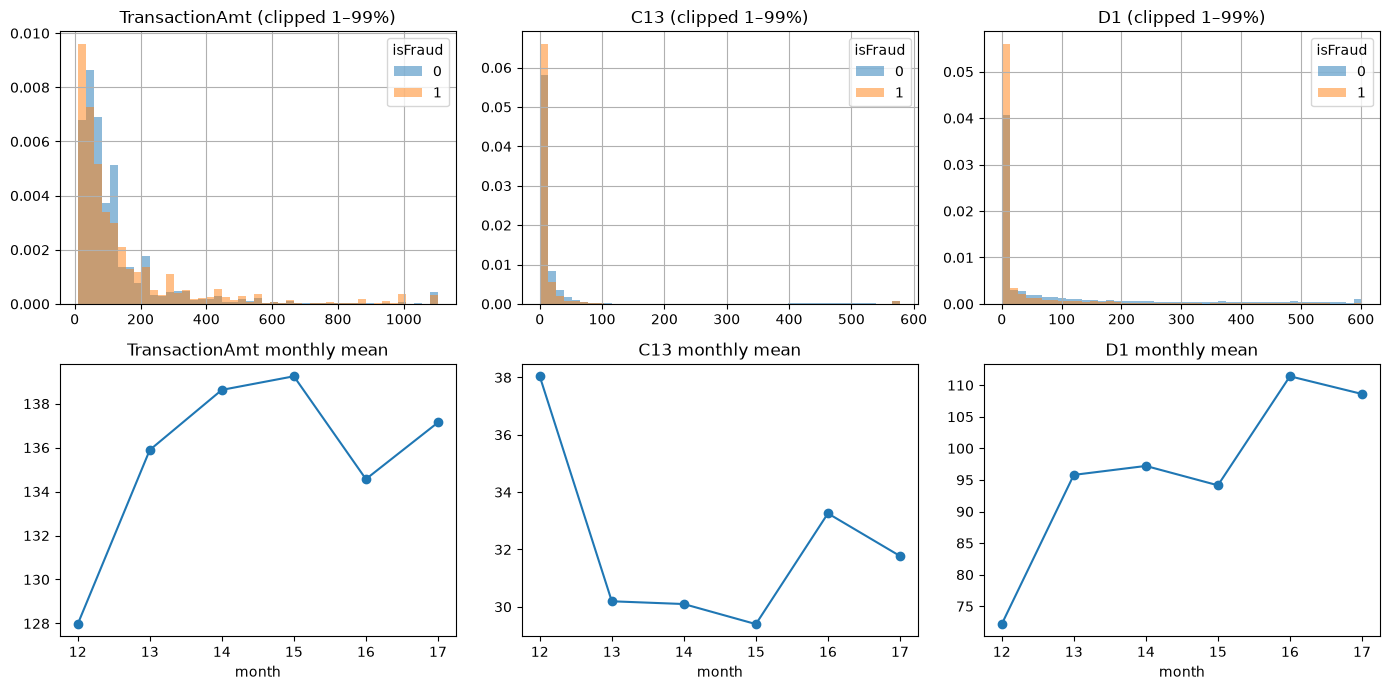

In [2]:
profile = pd.DataFrame({'dtype': train.dtypes.astype(str), 'train_missing': train.isna().mean(),
                        'test_missing': test.isna().mean(), 'train_unique': train.nunique(), 'test_unique': test.nunique()})
first150 = list(header[:150].drop(['TransactionID', 'isFraud']))
display(profile.loc[first150].head(20))
NUMERIC = ['TransactionAmt', 'C1', 'C13', 'C14', 'D1', 'D3', 'D15', 'V3', 'V127', 'V313']
summary = train[NUMERIC].groupby(train.isFraud).agg(['count', 'mean', 'std', 'median'])
display(summary.T)
for col in ['ProductCD', 'P_emaildomain', 'M4']:
    groups = train.groupby(col, observed=True).isFraud.agg(['size', 'mean'])
    display(groups.nlargest(10, 'size').rename(columns={'mean': 'fraud_rate'}))
fig, axes = plt.subplots(2, 3, figsize=(14, 7))
for col, ax in zip(['TransactionAmt', 'C13', 'D1'], axes[0]):
    limits = train[col].quantile([.01, .99])
    for label in [0, 1]:
        train.loc[train.isFraud.eq(label), col].clip(*limits).hist(bins=45, density=True, alpha=.5, ax=ax, label=str(label))
    ax.set_title(col + ' (clipped 1–99%)'); ax.legend(title='isFraud')
monthly = train.groupby('month')[['TransactionAmt', 'C13', 'D1']].mean()
for col, ax in zip(monthly, axes[1]):
    monthly[col].plot(marker='o', ax=ax, title=col + ' monthly mean')
plt.tight_layout(); plt.show()

### 이 표에서 다음 피처를 생각하는 방법
특정 C/D 값의 평균 차이를 발견했다면 우선 전체 히스토그램의 겹침과 월별 변화를 같이 봅니다. '사기 그룹의 평균이 높다'를 곧바로 임계값 규칙으로 만들지 마세요.
월별 수준 변화가 크다면 절대 값 대신 같은 고객/같은 시기 대비 평균·편차를 만드는 이유를 생각해볼 수 있습니다. 이것은 이후 코드의 집계/정규화와 연결되는 가설입니다.

## 2. V 결측 묶음과 상관관계 축소

### 같은 결측 위치는 같은 수집 과정을 의심할 단서입니다

거래 4개의 결측 마스크를 A=[0,1,0,1], B=[0,1,0,1], C=[1,0,1,0]이라고 해볼까요? 모두 2개가 비지만 A/B만 같은 거래에서 비었습니다.
그래서 아래 코드는 먼저 결측 개수로 묶고, 행별 마스크를 `packbits`로 압축해 SHA-256으로 비교합니다. **hash 값 자체는 모델 피처가 아니라 패턴을 비교하는 도구**입니다.

값의 관계는 Pearson 상관계수로 봅니다. +1에 가까우면 함께 커지고, -1이면 한쪽이 커질 때 다른 쪽이 작아지는 선형 관계입니다. 0이라고 모든 비선형 관계가 없는 것은 아닙니다.
pandas `corr()`는 두 열 모두 관측된 행에서 계산합니다. 결측이 많은 열의 상관은 적은 행에 근거할 수 있으며, 높은 상관만으로 완전 중복이나 같은 의미를 보장하지 않습니다.

V1–V11의 묶음 `[[1],[2,3],...]`은 원문이 정한 후보들입니다. 코드는 그 안에서 고유값이 가장 많은 열을 택합니다. 이는 다양성을 보존하려는 간단한 기준이지 사기 예측력이 가장 좋은 열을 직접 고른 것은 아닙니다.
상관행렬의 20,000행 표본은 계산량을 줄이는 설정입니다. 고정 seed는 그림을 재현하기 위한 것이고 희귀 패턴을 모두 포착한다는 보장은 아닙니다.

**왜 선택할 만한가?** 비슷한 열을 줄이면 메모리/학습 비용이 줄고 특징 실험도 쉬워집니다. 다만 tree는 상관된 열도 다룰 수 있으므로 선택 전/후 AUC로 정보 손실을 확인해야 합니다.

,missing_count,columns,distinct_masks,V_columns
0,12,32,1,"V279, V280, V284, V285, V286, V287, V290, V291..."
1,314,43,1,"V95, V96, V97, V98, V99, V100, V101, V102, V10..."
2,1269,11,1,"V281, V282, V283, V288, V289, V296, V300, V301..."
3,76073,23,1,"V12, V13, V14, V15, V16, V17, V18, V19, V20, V..."
4,77096,22,1,"V53, V54, V55, V56, V57, V58, V59, V60, V61, V..."
5,89164,20,1,"V75, V76, V77, V78, V79, V80, V81, V82, V83, V..."
6,168969,18,1,"V35, V36, V37, V38, V39, V40, V41, V42, V43, V..."
7,279287,11,1,"V1, V2, V3, V4, V5, V6, V7, V8, V9, V10, V11"
8,449124,16,1,"V220, V221, V222, V227, V234, V238, V239, V245..."
9,450721,19,1,"V169, V170, V171, V174, V175, V180, V184, V185..."


,candidate_group,max_unique_representative
0,[1],V1
1,"[2, 3]",V3
2,"[4, 5]",V4
3,"[6, 7]",V6
4,"[8, 9]",V8
5,"[10, 11]",V11


all_V                                         339
EDA_V                                         128
XGB_V                                         120
EDA_only    [96, 98, 99, 104, 325, 332, 335, 338]
dtype: object

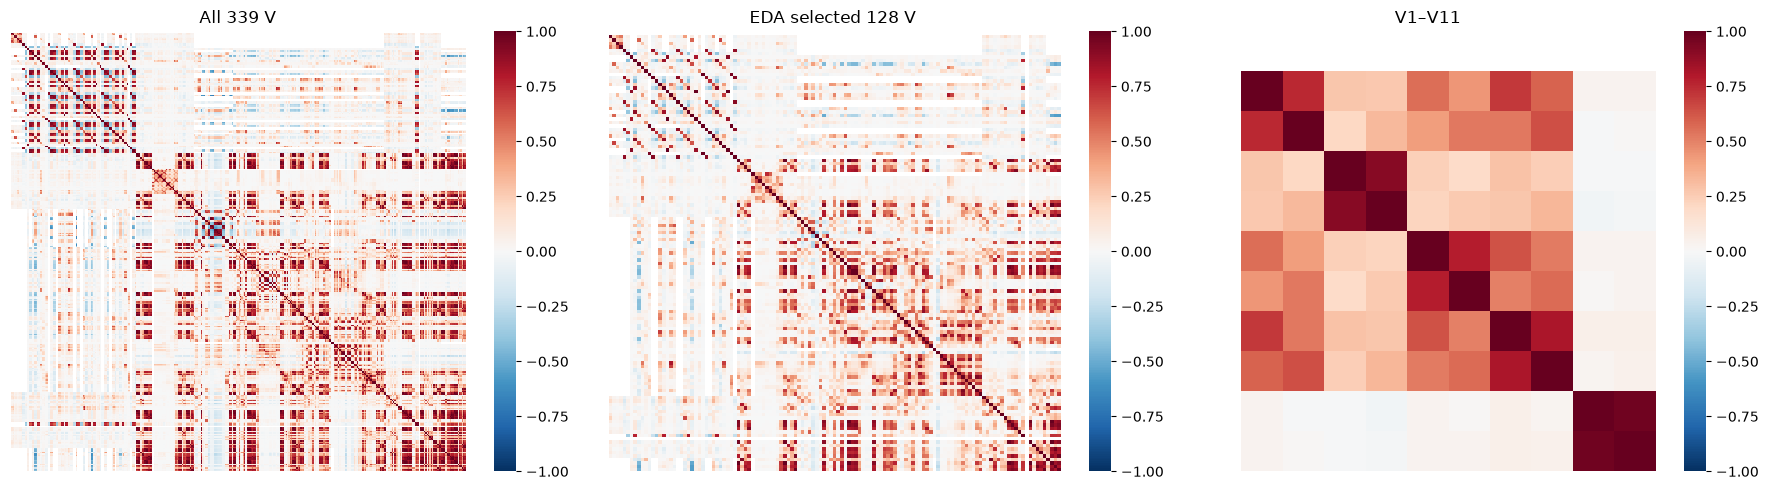

In [3]:
vs = [f'V{i}' for i in range(1, 340)]
missing = train[vs].isna()
counts = missing.sum()
rows = []
for count, columns in counts.groupby(counts):
    names = list(columns.index)
    patterns = {hashlib.sha256(np.packbits(missing[c].to_numpy()).tobytes()).hexdigest() for c in names}
    rows.append({'missing_count': int(count), 'columns': len(names), 'distinct_masks': len(patterns), 'V_columns': ', '.join(names)})
blocks = pd.DataFrame(rows)
display(blocks)
del missing
manual = [[1], [2, 3], [4, 5], [6, 7], [8, 9], [10, 11]]
selected = [train[[f'V{i}' for i in group]].nunique().idxmax() for group in manual]
display(pd.DataFrame({'candidate_group': manual, 'max_unique_representative': selected}))
eda_keep = sorted(set(V_KEEP + [96, 98, 99, 104, 332, 325, 335, 338]))
display(pd.Series({'all_V': len(vs), 'EDA_V': len(eda_keep), 'XGB_V': len(V_KEEP),
                   'EDA_only': [i for i in eda_keep if i not in V_KEEP]}))
corr_sample = train.sample(n=20000, random_state=42)
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for columns, title, ax in zip([vs, [f'V{i}' for i in eda_keep], [f'V{i}' for i in range(1, 12)]],
                             ['All 339 V', 'EDA selected 128 V', 'V1–V11'], axes):
    sns.heatmap(corr_sample[columns].corr(), cmap='RdBu_r', vmin=-1, vmax=1, ax=ax, xticklabels=False, yticklabels=False)
    ax.set_title(title)
plt.tight_layout(); plt.show()

### 실제 관찰을 선택 목록과 연결하기
저장된 전체 결과에서 V339는 결측 개수로 15묶음이고 각 묶음의 마스크도 1개였습니다. V1–V11 대표는 V1/3/4/6/8/11로 원문과 같습니다.
EDA의 V128에서 XGB가 쓰는 V120으로 갈 때 V96/98/99/104와 V325/332/335/338을 추가 제외합니다. **이 셀의 상관 분석이 그 8개의 제외 효과까지 측정한 것은 아닙니다.** 시간 일관성과 모델 검증을 연결해서 읽어야 합니다.

## 3. ID와 C/D/M의 분포·시간 관계

### identity 안에서의 결측과 전체 거래에서의 결측은 다릅니다

거래 100개 중 identity 행이 30개이고 그중 특정 ID 값이 20개라면, identity 안의 결측률은 10/30≈33.3%, 전체 거래 기준은 80/100=80%입니다.
아래 `identity_missing`과 `transaction_missing`이 이 차이를 보여줍니다. 어느 분모인지 모르면 같은 열을 보고도 정반대 인상을 받을 수 있습니다.

문자열 ID는 사람이 정한 숫자로 표시합니다. `Found/New/Unknown`을 1/3/0으로 바꾼 것은 **해당 범주의 크기나 간격을 증명한 것이 아닙니다.** 이 숫자로 구한 Pearson 상관은 그 코딩 방식에도 의존합니다.
M4의 M0/M1/M2도 여기서는 상관 그림용 코드입니다. 범주끼리 실제 순서가 있다는 보장은 없습니다. 자유 문자열 id_30/id_31 등은 숫자 상관에서 제외합니다.

시간과의 높은 상관은 '시기가 지나며 값이 변한다'는 조사 단서입니다. 그것이 사기를 설명하는지, 수집 정책이 바뀐 흔적인지는 별도 질문입니다.
**해볼 분석:** 의심되는 열을 월별 결측률/빈도표로 다시 봅니다. 숫자 하나의 상관계수로는 범주 전환이나 특정 월의 변화가 가려질 수 있습니다.

,dtype,identity_missing,transaction_missing,unique,test_unique
id_01,float64,0.000000,0.755761,77,80
id_02,float64,0.023303,0.761452,115655,114868
id_03,float64,0.540161,0.887689,24,22
id_04,float64,0.540161,0.887689,15,15
id_05,float64,0.051084,0.768238,93,90
id_06,float64,0.051084,0.768238,101,101
id_07,float64,0.964259,0.991271,84,81
id_08,float64,0.964259,0.991271,94,90
id_09,float64,0.480521,0.873123,46,38
id_10,float64,0.480521,0.873123,62,52


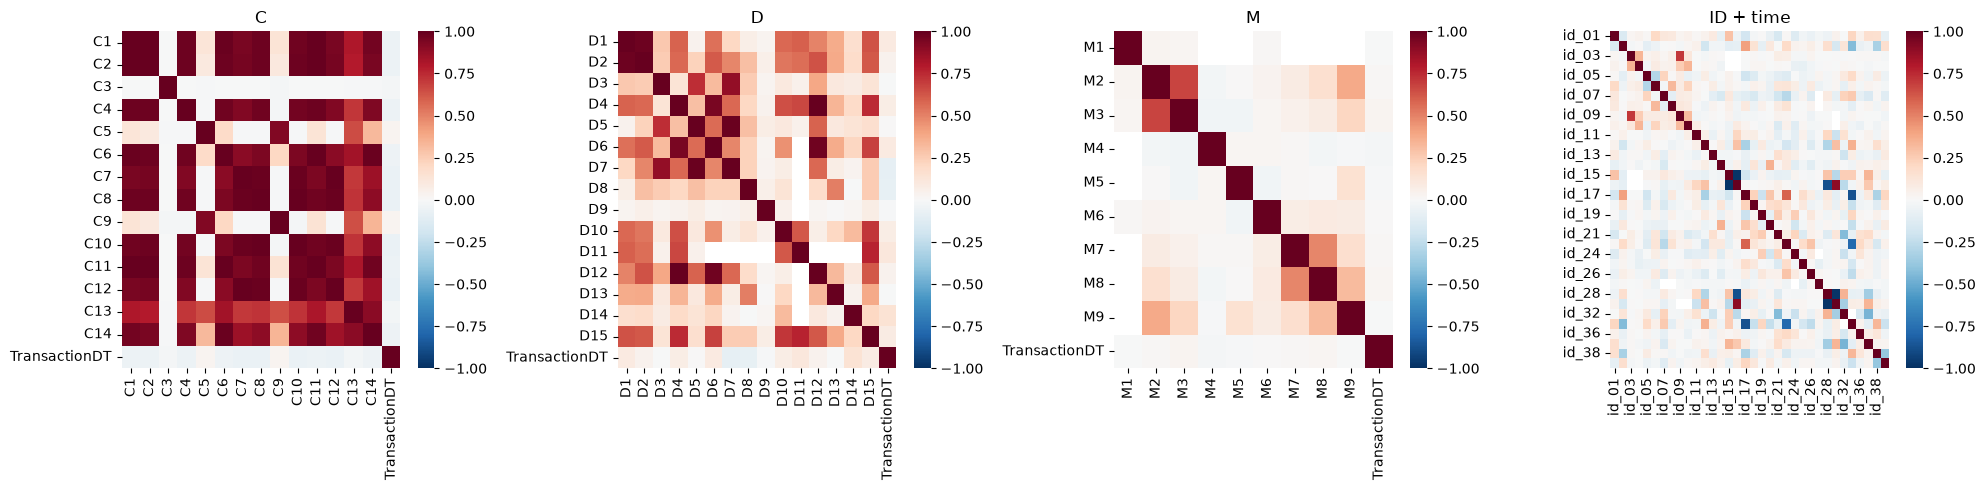

In [4]:
ids = [f'id_{i:02}' for i in range(1, 39)]
id_profile = pd.DataFrame({'dtype': train_id.dtypes.astype(str), 'identity_missing': train_id.isna().mean(),
                           'transaction_missing': train_id.reindex(train.index).isna().mean(),
                           'unique': train_id.nunique(), 'test_unique': test_id.nunique()})
display(id_profile)
id_numeric = train_id[ids].copy()
boolean = ['id_12', 'id_15', 'id_16', 'id_27', 'id_28', 'id_29', 'id_35', 'id_36', 'id_37', 'id_38']
mapping = {'Unknown': 0, 'NotFound': 1, 'Found': 2, 'New': 3, 'F': 0, 'T': 1}
for col in boolean:
    id_numeric[col] = id_numeric[col].map(mapping)
id_numeric['TransactionDT'] = train.TransactionDT.reindex(id_numeric.index)
fig, axes = plt.subplots(1, 4, figsize=(20, 5))
groups = [[f'C{i}' for i in range(1, 15)], [f'D{i}' for i in range(1, 16)], [f'M{i}' for i in range(1, 10)]]
for columns, title, ax in zip(groups, ['C', 'D', 'M'], axes[:3]):
    frame = corr_sample[columns + ['TransactionDT']].copy()
    if title == 'M':
        for col in columns:
            frame[col] = frame[col].map({'F': 0, 'T': 1, 'M0': 0, 'M1': 1, 'M2': 2}).astype('float32')
    sns.heatmap(frame.corr(), cmap='RdBu_r', vmin=-1, vmax=1, ax=ax); ax.set_title(title)
sns.heatmap(id_numeric.select_dtypes('number').corr(), cmap='RdBu_r', vmin=-1, vmax=1, ax=axes[3]); axes[3].set_title('ID + time')
plt.tight_layout(); plt.show()

## 4. 간단 UID와 공개 정밀 UID의 순도

### UID는 익명 거래를 '같은 고객일 가능성이 있는 그룹'으로 묶습니다

카드 코드와 주소만 같다고 반드시 같은 카드 소유자는 아닙니다. 여기에 D1이 나타내는 시간차를 사용해 시작 시점을 추정합니다.
100일째 D1=20, 105일째 D1=25인 두 거래는 `day-D1=80`으로 같아집니다. 실제 의미가 그 가정과 맞는다면 다른 날짜의 거래를 같은 그룹으로 묶을 단서가 됩니다.
그러나 D1의 자세한 의미나 그룹의 동일인 여부는 확정된 정답이 아닙니다. 이 노트북의 단순 UID는 D1/addr1 결측 행을 제외합니다.

`purity`는 그룹을 만들고 정답을 확인합니다. 여러 거래의 정답이 [0,0,0]이면 정상만, [1,1]이면 사기만, [0,1]이면 mixed입니다.
**순도 표의 비율 분모는 2건 이상인 그룹 수**입니다. 거래 수로 가중한 비율이나 전체 거래의 비율이 아닙니다. 단일 거래 그룹은 순도 100%가 자명해 이 비교에서 제외합니다.

공개 v3/v4/v1은 서로 다른 UID 파일입니다. `reindex`해서 누락 ID와 미확정 UID를 NaN으로 남깁니다. train에서 같은 번호가 발견되면 seen, 매칭 UID가 없으면 unresolved입니다.
**UID 번호가 train에 없다는 것과 실제 고객이 새로운 사람이라는 것은 같지 않을 수 있습니다.** 파일 간 번호 체계와 복원 범위가 다르면 실제 같은 사람도 연결되지 않습니다.
이 때문에 한 버전의 결과를 모든 고객의 진실로 해석하지 않고 버전별 커버리지와 연결률을 함께 봅니다.

In [5]:
def simple_uid(frame):
    issue_day = np.floor(frame.TransactionDT / 86400 - frame.D1)
    uid = frame.card1.astype(str) + '_' + frame.addr1.astype(str) + '_' + issue_day.astype(str)
    return uid.mask(frame.D1.isna() | frame.addr1.isna())

def purity(uid):
    group = train.groupby(uid).isFraud.agg(['size', 'nunique', 'mean'])
    multi = group[group['size'] > 1]
    return pd.Series({'mapped_rows': int(uid.notna().sum()), 'groups': len(group), 'multi_groups': len(multi),
                      'multi_all_normal': multi['mean'].eq(0).mean(), 'multi_all_fraud': multi['mean'].eq(1).mean(),
                      'multi_mixed': multi['nunique'].gt(1).mean()})
released = get_released_dir()
precise = {}
for split, frame in [('train', train), ('test', test)]:
    uid = pd.read_csv(released / f'{split}_uids_full_v3.csv', usecols=['TransactionID', 'uid']).set_index('TransactionID').uid
    assert uid.index.is_unique
    precise[split] = uid.reindex(frame.index).where(lambda s: s > 0)
display(pd.DataFrame({'simple_raw': purity(simple_uid(train)), 'released_v3': purity(precise['train'])}).T)
known = set(precise['train'].dropna())
client_type = pd.Series(np.where(precise['test'].isna(), 'unresolved', np.where(precise['test'].isin(known), 'seen_train', 'uid_not_seen')), index=test.index)
display(client_type.value_counts().to_frame('rows').assign(fraction=lambda d: d.rows / len(test)))
monthly = train.groupby('month').isFraud.agg(['size', 'mean'])
display(monthly.rename(columns={'mean': 'fraud_rate'}))
from data.winner import PP_FILES
version_comparison = []
for name in PP_FILES:
    uid = pd.read_csv(released / name, usecols=['TransactionID', 'uid']).set_index('TransactionID').uid
    fit_uid, test_uid = uid.reindex(train.index), uid.reindex(test.index)
    stats = purity(fit_uid).to_dict()
    stats.update({'file': name, 'test_coverage': test_uid.notna().mean(),
                  'test_seen_train': test_uid.isin(set(fit_uid.dropna())).mean()})
    version_comparison.append(stats)
display(pd.DataFrame(version_comparison).set_index('file'))

,mapped_rows,groups,multi_groups,multi_all_normal,multi_all_fraud,multi_mixed
simple_raw,523746.0,199070.0,83557.0,0.967495,0.017760,0.014744
released_v3,556249.0,312787.0,73342.0,0.972962,0.025047,0.001991


,rows,fraction
uid_not_seen,474767,0.936995
unresolved,31924,0.063005


,size,fraud_rate
month,,
12,137321,0.025852
13,92585,0.040017
14,86021,0.040072
15,101632,0.039545
16,83655,0.033806
17,89326,0.034861


,mapped_rows,groups,multi_groups,multi_all_normal,multi_all_fraud,multi_mixed,test_coverage,test_seen_train
file,,,,,,,,
uids_v4_no_multiuid_cleaning..csv,449351.0,251559.0,72044.0,0.969796,0.028857,0.001346,0.693350,0.095946
uids_v1_no_multiuid_cleaning.csv,498104.0,306173.0,68899.0,0.971291,0.027591,0.001118,0.719484,0.093842


### 순도가 높다는 관찰의 의미와 한계
v3 다중거래 그룹의 mixed 비율은 약 .20%, 단순 UID는 약 1.47%였습니다. 더 정밀하게 묶으면 같은 정답을 공유하는 그룹이 많다는 진단입니다.
v3의 train/test 번호 교집합은 없었지만 PP v4/v1에서는 test의 약 9.6%/9.4%가 train UID와 매칭됐습니다. v3 결과만으로 'test는 전부 새 고객'이라고 결론내리면 안 됩니다.
**해볼 검증:** UID 그룹을 통째로 나눈 검증과 시간 검증을 각각 해보세요. 고객 암기와 새 고객 일반화를 얼마나 구분하는지 다른 질문에 답할 수 있습니다.

## 5. 시간 일관성: 첫 월에서 학습 → 마지막 월에서 검증

### 첫 달에 배운 규칙이 마지막 달에도 통할까요?

단일 피처로 작은 LightGBM을 첫 월에 학습하고 마지막 월에 평가합니다. 값이 높을수록 사기로 배웠는데 마지막 월에는 반대라면 AUC가 .5 아래로 내려갈 수 있습니다.
예를 들어 첫 월의 큰 값들이 주로 사기였고 마지막 월의 큰 값들이 주로 정상이라면, 학습 당시 유용한 규칙이 미래에는 순서를 거꾸로 매깁니다.

`first_month_auc`는 학습한 행을 다시 예측한 **in-sample 진단**입니다. 독립 검증 점수가 아닙니다. 더 중요한 비교는 같은 모델이 마지막 월의 정답을 맞추는 `last_month_auc`입니다.
`num_leaves=8`과 500 trees는 복잡한 규칙을 과하게 늘리지 않으려는 진단 설정입니다. 이 노트북은 튜닝해서 최고의 모델을 찾는 단계가 아닙니다.

결측률도 함께 보세요. 값과 사기의 관계가 바뀌었을 수도 있지만 **결측/관측된 거래의 구성**이 달라진 영향도 있습니다.
단일 열이 실패해도 다른 열과 함께는 도움이 될 수 있습니다. 삭제 여부는 다변량 모델에서 해당 피처를 뺀 ablation으로 확인해야 합니다.
또한 두 월 사이에 표본 수와 사기 건수의 차이가 있으므로 작은 AUC 차이만으로 단정하지 않습니다.

In [6]:
first, last = train.month.min(), train.month.max()
checks = train[['C3', 'C7', 'V322', 'V325', 'V332', 'V338']].copy()
checks['id_38'] = train_id.id_38.map({'F': 0, 'T': 1}).reindex(train.index)
fit, val = train.month.eq(first), train.month.eq(last)
rows = []
for col in checks:
    model = lgb.LGBMClassifier(n_estimators=500, num_leaves=8, learning_rate=.02, n_jobs=8, verbosity=-1, random_state=42)
    model.fit(checks.loc[fit, [col]], train.loc[fit, 'isFraud'])
    rows.append({'feature': col, 'first_month_auc': roc_auc_score(train.loc[fit, 'isFraud'], model.predict_proba(checks.loc[fit, [col]])[:, 1]),
                 'last_month_auc': roc_auc_score(train.loc[val, 'isFraud'], model.predict_proba(checks.loc[val, [col]])[:, 1]),
                 'first_missing': checks.loc[fit, col].isna().mean(), 'last_missing': checks.loc[val, col].isna().mean()})
consistency = pd.DataFrame(rows).set_index('feature')
display(consistency)

,first_month_auc,last_month_auc,first_missing,last_missing
feature,,,,
C3,0.504236,0.502194,0.000000,0.000000
C7,0.652007,0.667188,0.000000,0.000000
V322,0.570293,0.476004,0.676619,0.890648
V325,0.566559,0.469104,0.676619,0.890648
V332,0.588729,0.490087,0.676619,0.890648
V338,0.573697,0.478044,0.676619,0.890648
id_38,0.608144,0.356193,0.581390,0.794808


### 방향이 뒤집힌 열을 어떻게 다룰까요?
저장된 AUC는 C7 .652→.667, V325 .567→.469, id_38 .608→.356입니다. V322–V339 블록 결측률도 약 67.7%→89.1%로 늘었습니다.
C7은 이 진단에서 방향이 유지됐고 V/ID 일부는 그렇지 않았습니다. '제외하면 이긴다'는 결론까지 얻은 것은 아닙니다.
**해볼 실험:** 같은 시간 holdout에서 전체 모델과 해당 블록을 뺀 모델을 비교합니다. 월별/관측 여부별 AUC를 같이 보면 평균 점수 뒤에 숨은 실패를 찾을 수 있습니다.

## 관찰과 모델로 이어지는 점
실행된 표/그림에서 관찰을 기록한다. V 대표 선택은 원문 목록을 유지하며 새로운 자동 선택 실험과 섞지 않는다.
간단 UID는 집계 입력, 공개 정밀 UID는 진단/PP 입력이라는 역할 차이를 유지한다.
공개 UID 누락률과 그룹 라벨 혼합을 측정했으므로 모든 고객의 라벨이 항상 동일하다고 단정하지 않는다.
월별 CV, 미래 holdout, known/unknown 고객 검증은 서로 다른 질문에 답한다. 원문의 보고 수치와 로컬 재현 결과를 별도로 기록한다.

전체 CSV 실행에서 V339는 결측 개수 기준 15묶음이고 각 묶음의 실제 결측 마스크도 1개였다. V1–V11 대표는 V1/3/4/6/8/11로 원문과 일치했다.
공개 v3의 다중거래 그룹 라벨 혼합률은 약 0.20%, 간단 UID는 약 1.47%였다. v3에서 train/test 공통 UID가 관찰되지 않아 이 버전으로 고객 재등장률을 판정하기 어렵다. PP v4/v1에서는 test의 약 9.6%/9.4%가 train에서 관찰된 UID에 매칭됐다. 이는 원문 private test 고객 구성 비율과 다른 모집단/UID 버전이다.
첫 월→마지막 월 AUC는 C7 .652→.667, V325 .567→.469, id_38 .608→.356이었다. V322–V339 블록 결측률도 약 67.7%→89.1%로 증가했다. 시간 일관성 진단의 필요성을 보여주며 전체 모델 피처 선택의 최종 결론은 아니다.